## Question 1: 
What is machine learning, and what is our goal here? In your own words, define the goal of machine learning (briefly). What kind of prediction could we make using this dataset? What variable seems like a good target?

- Machine learning is using the past to predict the future: training models created using current data to then use it to make predictions about future data
- goal of machine learning: to predict future patterns using current data
- I think a good variable to be a target is danceability, predicting how danceable a song is based on its energy, key, loudness, etc. 

## Preliminary data summary analysis

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # normalize data
df=pd.read_csv("top2019.csv")
non_numeric=['id','name','artists']
numeric=df.columns.difference(non_numeric)
scaler=MinMaxScaler()
df[numeric]=scaler.fit_transform(df[numeric])
ndf=df[numeric]

In [7]:
ndf.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0,50.000000
mean,0.302456,0.662590,0.367527,0.622472,0.037277,0.480000,0.198609,0.698220,0.580000,0.284919,0.453028,0.0,0.445264
std,0.262441,0.234456,0.183214,0.214061,0.179413,0.299570,0.195174,0.229921,0.498569,0.297711,0.263995,0.0,0.263394
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.093301,0.551259,0.260401,0.515763,0.000000,0.181818,0.081731,0.628448,0.000000,0.071315,0.240757,0.0,0.253005
50%,0.245531,0.705036,0.334235,0.646910,0.000000,0.454545,0.128030,0.737872,1.000000,0.151301,0.413529,0.0,0.450721
75%,0.456505,0.833633,0.424218,0.783417,0.000017,0.727273,0.220890,0.861364,1.000000,0.491329,0.609666,0.0,0.621394
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000


In [8]:
from sklearn.model_selection import train_test_split
X=ndf[['key','tempo','instrumentalness']]
y=ndf['danceability']
Xtrain, Xtest, ytrain, ytest=train_test_split(X,y,test_size=0.2, random_state=1)

In [9]:
Xtrain.shape

(40, 3)

In [10]:
ytrain.shape

(40,)

In [11]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(Xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
model1.coef_

array([0.14396505, 0.26929119, 0.15743137])

In [13]:
model1.intercept_

np.float64(0.4534151448373086)

- inputs all have positive slopes meaning they all have proportional relationships to the target (danceability)
    - eg. if you increase key it increases danceability, etc.
- for every increase in danceability key increases by 14%, tempo increases by 27% and instrumentalness increases by 16%

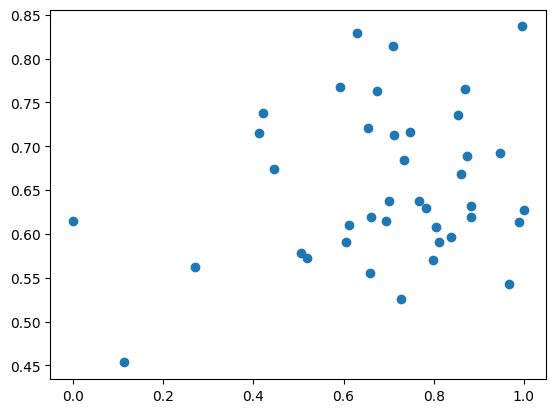

In [41]:
ypredict1=model1.predict(Xtest)
plt.scatter(ytest,ypredict1)

- if the model was accurate i feel like it shouldve looked more linear? 

In [42]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X, y, test_size=0.8, random_state=67)

In [43]:
model2=LinearRegression()
Xtrain.shape

(10, 3)

In [44]:
ytrain.shape

(10,)

In [45]:
model2.fit(Xtrain,ytrain)
ypredict2=model2.predict(Xtest)

In [46]:
model2.coef_

array([ 1.78813697e-01, -1.76384051e-02,  2.47682299e+02])

In [47]:
model2.intercept_

np.float64(0.5200741481429912)

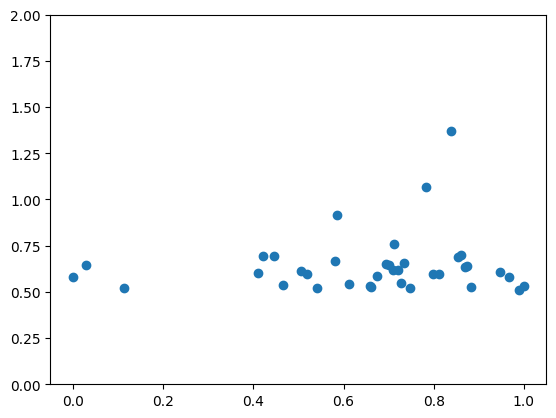

In [48]:
plt.ylim(0, 2)
plt.scatter(ytest,ypredict2)

## Accuracy Evaluation
- not accurate predicting the same thing for all test values


In [49]:
ndf.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0,50.000000
mean,0.302456,0.662590,0.367527,0.622472,0.037277,0.480000,0.198609,0.698220,0.580000,0.284919,0.453028,0.0,0.445264
std,0.262441,0.234456,0.183214,0.214061,0.179413,0.299570,0.195174,0.229921,0.498569,0.297711,0.263995,0.0,0.263394
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.093301,0.551259,0.260401,0.515763,0.000000,0.181818,0.081731,0.628448,0.000000,0.071315,0.240757,0.0,0.253005
50%,0.245531,0.705036,0.334235,0.646910,0.000000,0.454545,0.128030,0.737872,1.000000,0.151301,0.413529,0.0,0.450721
75%,0.456505,0.833633,0.424218,0.783417,0.000017,0.727273,0.220890,0.861364,1.000000,0.491329,0.609666,0.0,0.621394
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000


In [50]:
X2=ndf[['acousticness','duration_ms','energy','instrumentalness','key','liveness','loudness','mode','speechiness','tempo','time_signature','valence']]
y2=ndf['danceability']

In [51]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.8,random_state=69)

In [52]:
model3=LinearRegression()
model3.fit(Xtrain,ytrain)
ypredict3=model3.predict(Xtest)

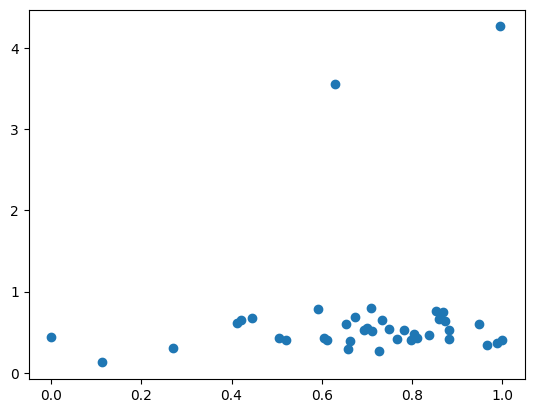

In [53]:
plt.scatter(ytest,ypredict3)

<Axes: >

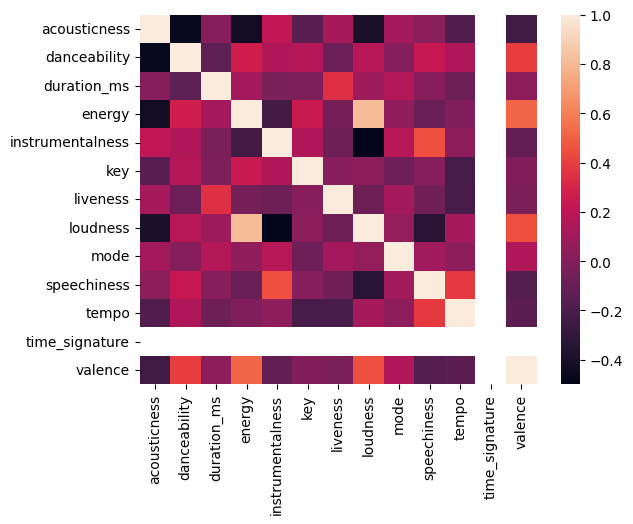

In [54]:
sns.heatmap(ndf.corr())

- acousticness most negatively correlated and valence is most positively correlated
- we should include them in our model because it influences it the most
  

## Reflect: How Do We Make a Good Model? 
Write 2–3 sentences on what makes a model good. What would you do next if you were trying to make this prediction model even better?

a model is good if it can accurate predict the y training values from the x training and also predict ytest values from ypredict before eventually predicting future projected values. To make it better I think we should drop the values that are very uncorrelated and emphasize the influence of the more correlated values 

## R^2 and MSE

In [55]:
from sklearn.metrics import r2_score, mean_squared_error
r2_1=r2_score(ytest,ypredict1)
r2_2=r2_score(ytest,ypredict2)
r2_3=r2_score(ytest,ypredict3)
mse1=mean_squared_error(ytest,ypred1)
mse2=mean_squared_error(ytest,ypred2)
mse3=mean_squared_error(ytest,ypred3)
print(f"model 1 \nr^2:{r2_1}\nmse:{mse1} \nmodel 2 \nr^2:{r2_2}\nmse:{mse2} \nmodel 3 \nr^2:{r2_3}\nmse:{mse3}")

model 1 
r^2:-0.010318947682139479
mse:0.05026947387442582 
model 2 
r^2:-50662.60279206316
mse:2516.8956251139853 
model 3 
r^2:-10.455681063430323
mse:0.5699893694491438


## Which model, in your opinion, is the 'best'?
Try to make a clean table that shows the outputs and different accuracy measurements for
your models for this final comparison.


In [57]:
data = {
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'R²': [r2_1, r2_2, r2_3],
    'MSE': [mse1, mse2, mse3]
}

finaldf= pd.DataFrame(data)
print(finaldf)

     Model            R²          MSE
0  Model 1     -0.010319     0.050269
1  Model 2 -50662.602792  2516.895625
2  Model 3    -10.455681     0.569989
